# Stage 34 — M2(L3+L4) + ALC (CT)

**Hypothesis (RQ14):** ALC forces L3+L4 prototype activations to remain
anatomically anchored. Expected benefits:
- Reduce centroid drift (prototypes migrating to background)
- Increase purity (spatially precise → less class overlap)
- Minimal Dice cost (ALC is a prototype-level constraint, not encoder constraint)

**Pipeline:** Phase 2 of v8 two-phase pipeline.
- Warm-start encoder from `proto_seg_ct_pp2.pth` (plain M4 Phase 1)
- Train M2(L3+L4) with ALC (λ_ALC=0.05)
- Compare vs Stage 29 (no ALC): Dice=0.8656, eff.purity=0.649

**Success criteria:**
| Metric | Stage 29 (no ALC) | Target |
|--------|-------------------|---------|
| 3D Dice | 0.8656 | ≥ 0.855 |
| L3 purity | 0.486 | ≥ 0.55 |
| L4 purity | 0.774 | ≥ 0.80 |
| Effective purity | 0.649 | ≥ 0.70 |
| Mean centroid deviation | — | < 20px |

## 0. Config

In [ ]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

SEED = 42

# ── Phase 1 encoder (plain M4 diagnostic from Stage 32) ───────────────────────
PHASE1_CKPT = "checkpoints/proto_seg_ct_pp2.pth"

# ── Phase 2: M2(L3+L4) + ALC ─────────────────────────────────────────────────
PROTO_LEVELS = [3, 4]  # from max-gap filter in Stage 32
USE_LEVEL_ATTENTION = False
MODALITY = "ct"
SUFFIX = "_l3l4_alc"

# ── ALC hyperparameters ───────────────────────────────────────────────────────
LAMBDA_ALC = 0.05
ALC_START_PHASE = "B"  # ALC active from Phase B (after prototype projection)

# ── Push-pull (identical to Stage 29) ────────────────────────────────────────
LAMBDA_DIV = 0.001
LAMBDA_PUSH = 0.5
LAMBDA_PULL = 0.25

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE = 16
LR = 3e-4
WEIGHT_DECAY = 1e-5
PHASE_A_END = 20
PHASE_B_END = 80
PHASE_C_END = 100
VAL_EVERY = 5
PATIENCE = 15
PROJ_INTERVAL = 10

DATA_DIR = "data/pack/processed_data"
CKPT_DIR = "checkpoints"
LOG_DIR = "results/v8"

import pathlib

pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH = f"{CKPT_DIR}/proto_seg_ct{SUFFIX}.pth"
PROJ_PATH = f"{CKPT_DIR}/projected_prototypes_ct{SUFFIX}.pt"
LOG_PATH = f"{LOG_DIR}/train_curve_proto_ct{SUFFIX}.csv"
PRIORS_PT = f"{LOG_DIR}/anatomical_priors_ct.pt"
PRIORS_CSV = f"{LOG_DIR}/anatomical_priors_ct.csv"

print(f"Phase 1 encoder  : {PHASE1_CKPT}")
print(f"PROTO_LEVELS     : {PROTO_LEVELS}")
print(f"lambda_alc       : {LAMBDA_ALC}")
print(f"Output ckpt      : {CKPT_PATH}")
print(f"Log              : {LOG_PATH}")

Phase 1 encoder  : checkpoints/proto_seg_ct_pp2.pth
PROTO_LEVELS     : [3, 4]
lambda_alc       : 0.05
Output ckpt      : checkpoints/proto_seg_ct_l3l4_alc.pth
Log              : results/v8/train_curve_proto_ct_l3l4_alc.csv


## 1. Imports & Device

In [2]:
import csv, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset,
    MMWHSPatientDataset,
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss
from src.losses.diversity_loss import ProtoSegLoss
from src.losses.alc_loss import (
    compute_anatomical_priors,
    anatomical_priors_to_csv,
    compute_centroid_deviation,
)
from src.metrics.dice import dice_per_class, mean_foreground_dice
from src.metrics.proto_quality import (
    compute_purity,
    compute_compactness,
    compute_per_level_ap,
    compute_level_dominance,
    compute_effective_quality,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
print(f"Device: {DEVICE}")

Device: mps


## 2. Data & Class Weights

In [3]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(
    f"Train: {len(loaders['train'].dataset)}  Val: {len(loaders['val'].dataset)}  Test: {len(loaders['test'].dataset)}"
)

class_weights = torch.load(f"data/class_weights_{MODALITY}.pt", weights_only=True)
print(f"Class weights: {class_weights.numpy().round(3)}")

Train: 3389  Val: 382  Test: 484
Class weights: [0.021 0.819 1.197 1.066 1.192 0.795 1.486 1.423]


## 3. Compute Anatomical Priors (μ_k)

Precompute mean centroid of each class from training labels.
Saved to disk; reloaded for training.

In [4]:
import pathlib

if pathlib.Path(PRIORS_PT).exists():
    print(f"Loading cached priors from {PRIORS_PT}")
    mu = torch.load(PRIORS_PT, weights_only=True)  # (K, 2)
else:
    print("Computing anatomical priors from training labels (first time, ~1 min)…")
    # Use a plain data loader (no model needed)
    prior_ds = MMWHSSliceDataset(
        DATA_DIR, MODALITY, "train", augment=False, preload=True
    )
    prior_loader = torch.utils.data.DataLoader(prior_ds, batch_size=64, shuffle=False)
    mu = compute_anatomical_priors(prior_loader, n_classes=NUM_CLASSES, device="cpu")
    torch.save(mu, PRIORS_PT)
    print(f"Saved: {PRIORS_PT}")

anatomical_priors_to_csv(mu, PRIORS_CSV, LABEL_NAMES)
print(f"Saved: {PRIORS_CSV}")

print(f"\nAnatomical priors μ_k (normalised [0,1]):")
print(f"{'Class':<12} {'y (row)':>10} {'x (col)':>10}")
print("─" * 34)
for k, name in enumerate(LABEL_NAMES):
    tag = "(BG, unused)" if k == 0 else ""
    print(f"{name:<12} {float(mu[k, 0]):>10.3f} {float(mu[k, 1]):>10.3f}  {tag}")

Loading cached priors from results/v8/anatomical_priors_ct.pt
Saved: results/v8/anatomical_priors_ct.csv

Anatomical priors μ_k (normalised [0,1]):
Class           y (row)    x (col)
──────────────────────────────────
0                 0.501      0.494  (BG, unused)
1                 0.628      0.580  
2                 0.442      0.388  
3                 0.612      0.571  
4                 0.308      0.561  
5                 0.487      0.680  
6                 0.388      0.539  
7                 0.452      0.395  


## 4. Load Phase 1 Encoder → Init M2(L3+L4)

Transfer encoder weights from plain M4 (Stage 32 checkpoint).
Decoder and prototype layers are randomly initialised.
**Key change vs Stage 29:** warm-start source is plain M4 (`proto_seg_ct_pp2.pth`),
not the attention M4 (`proto_seg_ct_l1234_attn_noent.pth`). This gives a
cleaner purity signal as the encoder was not shaped by the L2 feedback loop.

In [5]:
src_ckpt = torch.load(PHASE1_CKPT, map_location="cpu", weights_only=False)
print(
    f"Phase 1 checkpoint: epoch {src_ckpt['epoch']}, best_val {src_ckpt['best_val_dice']:.4f}"
)
print(
    f"  proto_levels={src_ckpt.get('proto_levels', 'None')}  use_attn={src_ckpt.get('use_level_attention', None)}"
)

# Init M2(L3+L4)
model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=PROTO_LEVELS,
    use_level_attention=USE_LEVEL_ATTENTION,
).to(DEVICE)

# Transfer encoder weights
src_state = src_ckpt["model_state_dict"]
own_state = model.state_dict()
transferred, skipped = [], []
for k, v in src_state.items():
    if k.startswith("encoder.") and k in own_state and own_state[k].shape == v.shape:
        own_state[k].copy_(v)
        transferred.append(k)
    else:
        skipped.append(k)
model.load_state_dict(own_state)

print(f"\nTransferred : {len(transferred)} encoder tensors")
print(f"Skipped     : {len(skipped)} (proto_layers, decoder — random init)")
print(
    f"Model       : proto_levels={model.proto_levels}  use_attn={model.use_level_attention}"
)
print(f"Total params: {model.count_parameters()['total']:,}")

# Sanity check: encoder differs from random init
fresh = ProtoSegNet(n_classes=NUM_CLASSES, proto_levels=PROTO_LEVELS).to("cpu")
src_p = next(p for n, p in model.named_parameters() if "encoder" in n)
fresh_p = next(p for n, p in fresh.named_parameters() if "encoder" in n)
diff = (src_p.cpu() - fresh_p).abs().mean().item()
print(f"\nEncoder diff vs random init: {diff:.4f}  (> 0 confirms warm-start active)")

Phase 1 checkpoint: epoch 90, best_val 0.8238
  proto_levels=None  use_attn=None

Transferred : 72 encoder tensors
Skipped     : 30 (proto_layers, decoder — random init)
Model       : proto_levels=[3, 4]  use_attn=False
Total params: 2,553,704

Encoder diff vs random init: 0.2146  (> 0 confirms warm-start active)


## 5. Loss Setup

In [6]:
seg_loss = SegmentationLoss(
    class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES
)

# Phase A: no ALC (prototypes are random; ALC before projection adds noise)
criterion_A = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
    lambda_alc=0.0,
)

# Phase B+: ALC active
criterion_B = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
    lambda_alc=LAMBDA_ALC,
    alc_mu=mu.to(DEVICE),
    alc_levels=PROTO_LEVELS,
)

print(f"Phase A criterion: ALC off")
print(f"Phase B+ criterion: lambda_alc={LAMBDA_ALC}, alc_levels={PROTO_LEVELS}")


@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch["image"].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch["label"])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


def run_projection(model, save_path):
    print("  [Proj] Building feature bank on CPU…", flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(
        DATA_DIR, MODALITY, "train", augment=False, preload=True
    )
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b["image"], b["label"]) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device="cpu",
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt["proto_state"].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f"  [Proj] Done in {time.time() - t0:.1f}s", flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        model.unfreeze_all()
        model.freeze_prototypes()
        phase = "A"
    elif epoch <= PHASE_B_END:
        model.unfreeze_all()
        phase = "B"
    else:
        model.freeze_encoder_and_prototypes()
        phase = "C"
    optimizer.param_groups[0]["params"] = [
        p for p in model.parameters() if p.requires_grad
    ]
    return phase


def save_checkpoint(epoch, model, best_val_dice):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_val_dice": best_val_dice,
            "proto_levels": model.proto_levels,
            "use_level_attention": model.use_level_attention,
            "class_weights": class_weights,
            "lambda_div": LAMBDA_DIV,
            "lambda_push": LAMBDA_PUSH,
            "lambda_pull": LAMBDA_PULL,
            "lambda_alc": LAMBDA_ALC,
            "source_checkpoint": PHASE1_CKPT,
            "single_scale": model.single_scale,
            "no_soft_mask": model.no_soft_mask,
            "hard_mask": model.hard_mask,
            "mask_quantile": model.mask_quantile,
            "hard_mask_active": model.hard_mask_active,
        },
        CKPT_PATH,
    )


print("Helpers ready.")

Phase A criterion: ALC off
Phase B+ criterion: lambda_alc=0.05, alc_levels=[3, 4]
Helpers ready.


## 6. Training Loop (3-Phase)

Phase A (1–20): encoder + decoder train, prototypes frozen. ALC OFF.
Phase B (21–80): all params + prototype projection every 10 ep. ALC ON.
Phase C (81–100): decoder fine-tunes only. ALC ON.

In [7]:
model.freeze_prototypes()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

fieldnames = [
    "epoch",
    "phase",
    "train_loss",
    "train_dice_loss",
    "train_ce_loss",
    "train_div_loss",
    "train_push_loss",
    "train_pull_loss",
    "train_alc_loss",
    "val_mean_fg_dice",
    "lr",
    "epoch_time_s",
] + [f"val_dice_{LABEL_NAMES[c]}" for c in range(1, NUM_CLASSES)]

csv_file = open(LOG_PATH, "w", newline="")
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = "A"

print(f"M2(L3+L4) + ALC  encoder from plain M4 ep {src_ckpt['epoch']}")
print(
    f"λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}  λ_ALC={LAMBDA_ALC} (Phase B+)"
)
print(f"Total epochs={PHASE_C_END}\n")

for epoch in range(1, PHASE_C_END + 1):
    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == "B":
            print(f"\n→ Phase B: all params + ALC (ep {PHASE_A_END + 1}–{PHASE_B_END})")
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == "C":
            print(
                f"\n→ Phase C: decoder only + ALC (ep {PHASE_B_END + 1}–{PHASE_C_END})"
            )

    # Prototype projection at start of Phase B, then every PROJ_INTERVAL epochs
    if (
        current_phase == "B"
        and epoch > PHASE_A_END + 1
        and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0
    ):
        run_projection(model, PROJ_PATH)

    # Select criterion
    criterion = criterion_A if current_phase == "A" else criterion_B

    t0 = time.time()
    model.train()
    totals = dict(
        loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0, alc_loss=0
    )
    n_batches = 0

    for batch in loaders["train"]:
        imgs = batch["image"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)
        if current_phase == "A":
            from src.losses.segmentation import SegmentationLoss

            out = seg_loss(logits, lbls)
            out["div_loss"] = out["push_loss"] = out["pull_loss"] = out["alc_loss"] = (
                torch.zeros(1, device=DEVICE)
            )
        else:
            out = criterion(logits, lbls, hm)
        out["loss"].backward()
        optimizer.step()
        for k in totals:
            v = out.get(k, torch.tensor(0.0))
            totals[k] += v.item() if hasattr(v, "item") else float(v)
        n_batches += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avgs = {k: v / n_batches for k, v in totals.items()}

    val_dice_dict = None
    val_mean = float("nan")
    if epoch % VAL_EVERY == 0 or epoch == PHASE_C_END:
        val_dice_dict = validate(model, loaders["val"])
        val_mean = mean_foreground_dice(val_dice_dict)
        improved = val_mean > best_val_dice
        if improved:
            best_val_dice = val_mean
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(epoch, model, best_val_dice)
        else:
            no_improve += VAL_EVERY
        mark = " ← best" if improved else ""
        print(
            f"  [{current_phase}] Ep {epoch:3d}/{PHASE_C_END} | "
            f"loss={avgs['loss']:.4f} "
            f"(D={avgs['dice_loss']:.4f} CE={avgs['ce_loss']:.4f} "
            f"div={avgs['div_loss']:.4f} push={avgs['push_loss']:.4f} "
            f"pull={avgs['pull_loss']:.4f} alc={avgs['alc_loss']:.4f}) | "
            f"val={val_mean:.4f}{mark} | "
            f"lr={scheduler.get_last_lr()[0]:.2e} | {epoch_time:.1f}s",
            flush=True,
        )

    row = {
        "epoch": epoch,
        "phase": current_phase,
        "train_loss": avgs["loss"],
        "train_dice_loss": avgs["dice_loss"],
        "train_ce_loss": avgs["ce_loss"],
        "train_div_loss": avgs["div_loss"],
        "train_push_loss": avgs["push_loss"],
        "train_pull_loss": avgs["pull_loss"],
        "train_alc_loss": avgs["alc_loss"],
        "val_mean_fg_dice": val_mean if val_dice_dict else None,
        "lr": scheduler.get_last_lr()[0],
        "epoch_time_s": epoch_time,
    }
    if val_dice_dict:
        for c in range(1, NUM_CLASSES):
            row[f"val_dice_{LABEL_NAMES[c]}"] = val_dice_dict.get(
                LABEL_NAMES[c], float("nan")
            )
    writer.writerow(row)
    csv_file.flush()

csv_file.close()
print(f"\nBest val Dice : {best_val_dice:.4f} at epoch {best_epoch}")
print(f"Checkpoint    : {CKPT_PATH}")

M2(L3+L4) + ALC  encoder from plain M4 ep 90
λ_div=0.001  λ_push=0.5  λ_pull=0.25  λ_ALC=0.05 (Phase B+)
Total epochs=100

  [A] Ep   5/100 | loss=0.0930 (D=0.1108 CE=0.0751 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8037 ← best | lr=2.98e-04 | 28.3s
  [A] Ep  10/100 | loss=0.0639 (D=0.0728 CE=0.0549 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8236 ← best | lr=2.93e-04 | 28.0s
  [A] Ep  15/100 | loss=0.0553 (D=0.0628 CE=0.0477 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8106 | lr=2.84e-04 | 28.0s
  [A] Ep  20/100 | loss=0.0503 (D=0.0572 CE=0.0434 div=0.0000 push=0.0000 pull=0.0000 alc=0.0000) | val=0.8206 | lr=2.71e-04 | 28.1s

→ Phase B: all params + ALC (ep 21–80)
  [B] Ep  25/100 | loss=0.9088 (D=0.1217 CE=0.1084 div=936.8600 push=-0.5073 pull=0.4374 alc=0.0225) | val=0.7804 ← best | lr=2.56e-04 | 32.8s
  [Proj] Building feature bank on CPU…
Projected prototypes saved → checkpoints/projected_prototypes_ct_l3l4_alc.pt
  [Proj] Done in 63.7s
  [B] Ep 

## 7. Training Curves

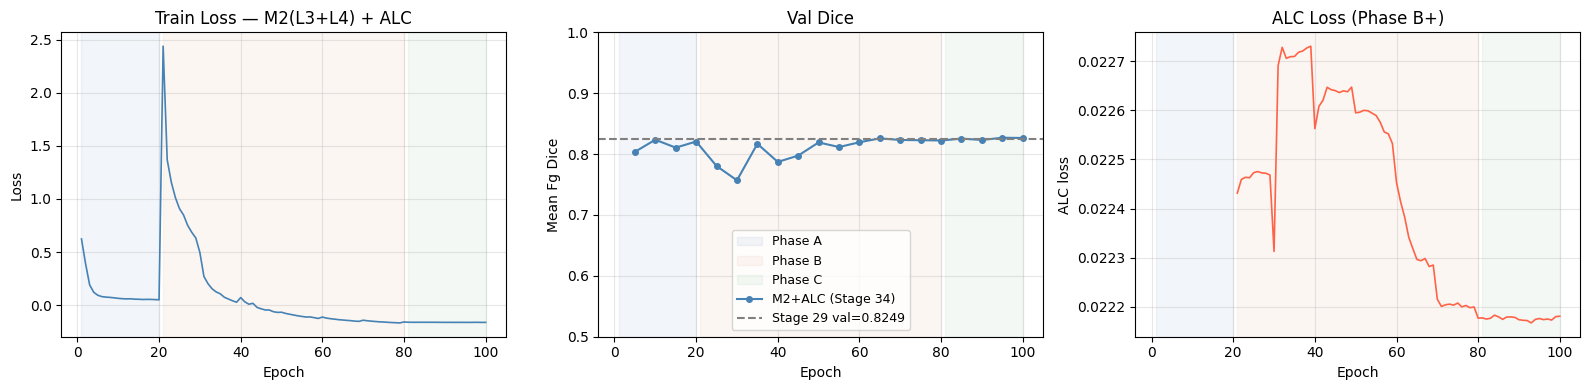

Best val: 0.8269 at ep 95


In [8]:
log = pd.read_csv(LOG_PATH)
val = log.dropna(subset=["val_mean_fg_dice"])

STAGE29_VAL = 0.8249  # best val Dice Stage 29
M2_3D = 0.8722
PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax in axes:
    for ph, color in PHASE_COLORS.items():
        mask = log["phase"] == ph
        if mask.any():
            ax.axvspan(
                log.loc[mask, "epoch"].min(),
                log.loc[mask, "epoch"].max(),
                alpha=0.07,
                color=color,
                label=f"Phase {ph}",
            )

axes[0].plot(log["epoch"], log["train_loss"], lw=1.2, color="steelblue")
axes[0].set(title="Train Loss — M2(L3+L4) + ALC", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    val["epoch"],
    val["val_mean_fg_dice"],
    "o-",
    ms=4,
    lw=1.5,
    color="steelblue",
    label="M2+ALC (Stage 34)",
)
axes[1].axhline(
    STAGE29_VAL, ls="--", lw=1.5, color="gray", label=f"Stage 29 val={STAGE29_VAL:.4f}"
)
axes[1].set(title="Val Dice", xlabel="Epoch", ylabel="Mean Fg Dice", ylim=(0.5, 1.0))
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# ALC loss curve (Phase B+)
alc_log = log[log["phase"] != "A"]
axes[2].plot(alc_log["epoch"], alc_log["train_alc_loss"], lw=1.2, color="tomato")
axes[2].set(title="ALC Loss (Phase B+)", xlabel="Epoch", ylabel="ALC loss")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{LOG_DIR}/train_curve_proto_ct{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    f"Best val: {val['val_mean_fg_dice'].max():.4f} at ep {int(val.loc[val['val_mean_fg_dice'].idxmax(), 'epoch'])}"
)

## 8. 3D Dice Evaluation

In [9]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=ckpt["proto_levels"],
    use_level_attention=ckpt.get("use_level_attention", False),
).to(DEVICE)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.eval()
print(
    f"Loaded epoch {ckpt['epoch']}  best_val {ckpt['best_val_dice']:.4f}  levels={ckpt['proto_levels']}"
)


@torch.no_grad()
def eval_3d(model):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, "test")
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


results_3d = eval_3d(eval_model)

BASELINES_3D = {
    "Stage 29 (no ALC, attn warm-start)": 0.8656,
    "M2 cold-start": 0.8722,
}

print(f"\n{'Patient':<12} {'MeanFg':>7}  " + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES))
print("─" * 75)
all_means = []
for pid, dice in sorted(results_3d.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
    print(f"{pid:<12} {mfg:>7.4f}  {vals}")

overall_3d = float(np.mean(all_means))
print("─" * 75)
print(f"{'Mean':<12} {overall_3d:>7.4f}")

print()
for bname, bval in BASELINES_3D.items():
    print(f"  Δ vs {bname:<40} : {overall_3d - bval:+.4f}")

print()
ok_dice = overall_3d >= 0.855
print(
    f"Target 3D Dice ≥ 0.855 : {'✅' if ok_dice else f'❌ ({overall_3d:.4f})'} (ΔDice vs Stage 29 = {overall_3d - 0.8656:+.4f})"
)

Loaded epoch 95  best_val 0.8269  levels=[3, 4]

Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7599  0.806  0.881  0.671  0.882  0.785  0.721  0.573
ct_1020       0.9356  0.891  0.964  0.940  0.918  0.926  0.974  0.935
───────────────────────────────────────────────────────────────────────────
Mean          0.8478

  Δ vs Stage 29 (no ALC, attn warm-start)       : -0.0178
  Δ vs M2 cold-start                            : -0.0244

Target 3D Dice ≥ 0.855 : ❌ (0.8478) (ΔDice vs Stage 29 = -0.0178)


## 9. Prototype Quality

In [10]:
train_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "train", augment=False, preload=True)
test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "test", augment=False, preload=True)
train_loader_pq = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader_pq = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

print("Computing prototype quality…")
purity_df = compute_purity(eval_model, train_loader_pq)
compact_df = compute_compactness(eval_model, test_loader_pq)
ap_df = compute_per_level_ap(eval_model, test_loader_pq)
dom_df = compute_level_dominance(eval_model, test_loader_pq)

purity_l = purity_df.groupby("level")["purity"].mean()
compact_l = compact_df.groupby("level")["compactness"].mean()
ap_l = ap_df.groupby("level")["ap"].mean()

print(f"\n{'Level':<6} {'Purity':>7} {'AP':>7} {'Compact':>8} {'Dominance':>10}")
print(f"{'------':<6} {'-------':>7} {'-------':>7} {'--------':>8} {'----------':>10}")
for l in PROTO_LEVELS:
    dom = (
        float(dom_df[f"frac_l{l}"].values[0])
        if f"frac_l{l}" in dom_df.columns
        else float("nan")
    )
    print(
        f"L{l:<5} {purity_l.get(l, float('nan')):>7.3f} "
        f"{ap_l.get(l, float('nan')):>7.3f} "
        f"{compact_l.get(l, float('nan')):>8.3f} "
        f"{dom:>9.1%}"
    )

# Compare with Stage 29
STAGE29_PQ = {
    3: {"purity": 0.486, "ap": 0.213, "compact": 0.634, "dom": 0.434},
    4: {"purity": 0.774, "ap": 0.224, "compact": 0.402, "dom": 0.566},
}
print()
print("Delta vs Stage 29 (no ALC):")
for l in PROTO_LEVELS:
    p = float(purity_l.get(l, float("nan")))
    delta = p - STAGE29_PQ[l]["purity"]
    print(f"  L{l} purity: {p:.3f} (Δ={delta:+.3f} vs {STAGE29_PQ[l]['purity']:.3f})")

Computing prototype quality…

Level   Purity      AP  Compact  Dominance
------ ------- ------- -------- ----------
L3       0.646   0.181    0.481     35.5%
L4       0.670   0.177    0.390     64.5%

Delta vs Stage 29 (no ALC):
  L3 purity: 0.646 (Δ=+0.160 vs 0.486)
  L4 purity: 0.670 (Δ=-0.104 vs 0.774)


## 10. Effective Quality

In [11]:
eff = compute_effective_quality(purity_df, ap_df, compact_df, dom_df)
eff_p = float(eff["effective_purity"].values[0])
eff_ap = float(eff["effective_ap"].values[0])
eff_c = float(eff["effective_compactness"].values[0])

print("Effective quality (dominance-weighted aggregate):")
print(f"  effective_purity      = {eff_p:.3f}")
print(f"  effective_ap          = {eff_ap:.3f}")
print(f"  effective_compactness = {eff_c:.3f}")
print()
for l in PROTO_LEVELS:
    w = (
        float(eff[f"weight_l{l}"].values[0])
        if f"weight_l{l}" in eff.columns
        else float("nan")
    )
    p = (
        float(eff[f"purity_l{l}"].values[0])
        if f"purity_l{l}" in eff.columns
        else float("nan")
    )
    print(f"  L{l}: weight={w:.1%}  purity={p:.3f}×{w:.1%}={p * w:.3f}")

print()
print(f"Stage 29 effective purity = 0.649")
print(f"Stage 34 effective purity = {eff_p:.3f}  (Δ = {eff_p - 0.649:+.3f})")
ok_eff = eff_p >= 0.70
print(f"Target eff. purity ≥ 0.70 : {'✅' if ok_eff else f'❌ ({eff_p:.3f})'} ")

eff.to_csv(f"{LOG_DIR}/effective_quality_ct{SUFFIX}.csv", index=False)

Effective quality (dominance-weighted aggregate):
  effective_purity      = 0.661
  effective_ap          = 0.179
  effective_compactness = 0.423

  L3: weight=35.5%  purity=0.646×35.5%=0.230
  L4: weight=64.5%  purity=0.670×64.5%=0.432

Stage 29 effective purity = 0.649
Stage 34 effective purity = 0.661  (Δ = +0.012)
Target eff. purity ≥ 0.70 : ❌ (0.661) 


## 11. Centroid Deviation (New Metric)

In [12]:
print("Computing centroid deviation on test set…")
dev_df = compute_centroid_deviation(
    eval_model,
    test_loader_pq,
    mu=mu,
    active_levels=PROTO_LEVELS,
    image_size=256,
)

print(dev_df.to_string(index=False))

mean_dev = float(dev_df["mean_deviation_px"].mean())
print(f"\nMean centroid deviation: {mean_dev:.1f}px")
ok_dev = mean_dev < 20.0
print(f"Target < 20px : {'✅' if ok_dev else f'❌ ({mean_dev:.1f}px)'}")

dev_df.to_csv(f"{LOG_DIR}/centroid_deviation_ct{SUFFIX}.csv", index=False)
print(f"Saved: {LOG_DIR}/centroid_deviation_ct{SUFFIX}.csv")

Computing centroid deviation on test set…
 level  mean_deviation_px  n_terms
     3          37.231013     6776
     4          36.783340     6776

Mean centroid deviation: 37.0px
Target < 20px : ❌ (37.0px)
Saved: results/v8/centroid_deviation_ct_l3l4_alc.csv


## 12. Comparison Table

In [13]:
l3_purity = float(purity_l.get(3, float("nan")))
l4_purity = float(purity_l.get(4, float("nan")))
l3_dom = (
    float(dom_df["frac_l3"].values[0]) if "frac_l3" in dom_df.columns else float("nan")
)
l4_dom = (
    float(dom_df["frac_l4"].values[0]) if "frac_l4" in dom_df.columns else float("nan")
)

rows = [
    {
        "model": "Stage 29 (no ALC, attn warm-start)",
        "3d_dice": 0.8656,
        "purity_l3": 0.486,
        "purity_l4": 0.774,
        "effective_purity": 0.649,
        "mean_dev_px": None,
    },
    {
        "model": "Stage 34 (ALC λ=0.05, plain M4 warm-start)",
        "3d_dice": overall_3d,
        "purity_l3": l3_purity,
        "purity_l4": l4_purity,
        "effective_purity": eff_p,
        "mean_dev_px": mean_dev,
    },
    {
        "model": "M2 cold-start (best overall)",
        "3d_dice": 0.8722,
        "purity_l3": None,
        "purity_l4": 0.804,
        "effective_purity": None,
        "mean_dev_px": None,
    },
]
comp_df = pd.DataFrame(rows)
comp_df.to_csv(f"{LOG_DIR}/comparison_table_v8.csv", index=False)

print(comp_df.to_string(index=False))
print(f"\nSaved: {LOG_DIR}/comparison_table_v8.csv")

                                     model  3d_dice  purity_l3  purity_l4  effective_purity  mean_dev_px
        Stage 29 (no ALC, attn warm-start) 0.865600   0.486000      0.774          0.649000          NaN
Stage 34 (ALC λ=0.05, plain M4 warm-start) 0.847772   0.645714      0.670          0.661367    37.007177
              M2 cold-start (best overall) 0.872200        NaN      0.804               NaN          NaN

Saved: results/v8/comparison_table_v8.csv


## 13. RQ14 Verdict

In [14]:
print(
    "RQ14: Does ALC improve prototype anatomical precision (purity ↑, centroid deviation ↓)"
)
print("      within M2(L3+L4) without significant Dice cost (ΔDice ≤ 0.01)?")
print()

criteria = [
    (f"3D Dice ≥ 0.855 (ΔDice ≤ 0.01 vs Stage 29)", ok_dice),
    (f"L3 purity ≥ 0.55 (vs 0.486 Stage 29)", l3_purity >= 0.55),
    (f"L4 purity ≥ 0.80 (vs 0.774 Stage 29)", l4_purity >= 0.80),
    (f"Effective purity ≥ 0.70 (vs 0.649 Stage 29)", ok_eff),
    (f"Mean centroid deviation < 20px", ok_dev),
]

passed = sum(1 for _, ok in criteria if ok)
for desc, ok in criteria:
    print(f"  {'✅' if ok else '❌'}  {desc}")

print()
print(f"Result: {passed}/{len(criteria)} criteria met")
print()

if passed == len(criteria):
    print(
        "Verdict: RQ14 MET — ALC improves purity and anatomical anchoring with minimal Dice cost."
    )
    print(
        "→ Two-phase pipeline with ALC is validated. Proceed to Stage 35 (MR, optional) or Stage 36."
    )
elif passed >= 3:
    print(f"Verdict: RQ14 PARTIAL ({passed}/5).")
    if not ok_dice:
        print(
            f"  Dice dropped too much ({overall_3d:.4f} < 0.855). Consider reducing λ_ALC to 0.01."
        )
    if l3_purity < 0.55:
        print(
            f"  L3 purity still low ({l3_purity:.3f}). ALC at L3 level may need higher λ."
        )
    if not ok_eff:
        print(f"  Effective purity {eff_p:.3f} < 0.70.")
    print(
        "→ Proceed to Stage 36 with honest reporting. Consider λ_ALC sweep if time allows."
    )
else:
    print("Verdict: RQ14 NOT MET.")
    print("→ Reduce λ_ALC and retrain.")

RQ14: Does ALC improve prototype anatomical precision (purity ↑, centroid deviation ↓)
      within M2(L3+L4) without significant Dice cost (ΔDice ≤ 0.01)?

  ❌  3D Dice ≥ 0.855 (ΔDice ≤ 0.01 vs Stage 29)
  ✅  L3 purity ≥ 0.55 (vs 0.486 Stage 29)
  ❌  L4 purity ≥ 0.80 (vs 0.774 Stage 29)
  ❌  Effective purity ≥ 0.70 (vs 0.649 Stage 29)
  ❌  Mean centroid deviation < 20px

Result: 1/5 criteria met

Verdict: RQ14 NOT MET.
→ Reduce λ_ALC and retrain.
